# ABF with Fisher-Rao

## Potentials including metastability

### Example 1 - two-well soft barrier

$$
V(x, y) = 3 e^{-x^2} \!\left( e^{-(y-1/3)^2} - e^{-(y-5/3)^2} \right)
- 5 e^{-y^2} \!\left( e^{-(x-1)^2} + e^{-(x+1)^2} \right)
+ 0.2\, x^4 + 0.2 \, (y - 1/3)^4.
$$

### Example 2 - metastable quartic

$$
V(x, y) = \tfrac{1}{6} \left[ 4 (1 - x^2 - y^2)^2 + 2 (x^2 - 2)^2
+ ((x + y)^2 - 1)^2 + ((x - y)^2 - 1)^2 \right].
$$

### Boltzmann distribution and mean force

For each example the Boltzmann distribution is $\pi_\beta \propto e^{-\beta V}$,
the free energy along $x$ is
$$
F(z) = -\frac{1}{\beta} \ln \frac{Z(z)}{Z}, \qquad
Z(z) = \int e^{-\beta V(z, y)} \, dy, \qquad
Z = \int \!\! \int e^{-\beta V(x, y)} \, dx \, dy,
$$
and the local mean force is $f(x, y) = \partial_x V(x, y)$, so
$F'(z) = \mathbb{E}_\pi[\partial_x V(X, Y) \mid X = z]$.


## Theory of algorithm

We restrict the simulation to $[\text{ZMIN}, \text{ZMAX}] \times [\text{YMIN}, \text{YMAX}]$. Theoretically, the marginal of $\rho_t$ along the reaction coordinate is
$$
p_t(x) = \int_{\text{YMIN}}^{\text{YMAX}} \rho_t(x, y) \, dy.
$$
Practically, as integration in the non-ABF coordinates is difficult, we apply **kernel density estimation** to approximate the marginal distribution along the reaction coordinate

### Langevin dynamics with ABF

Let $A_t$ be the running ABF estimate of the free energy and $A_t'$ its
derivative. The biased Langevin dynamics is
$$
\begin{cases}
d X_t = (-\partial_x V(X_t, Y_t) + A_t'(X_t)) \, dt + \sqrt{2/\beta} \, dW_t^x, \\
d Y_t = -\partial_y V(X_t, Y_t) \, dt + \sqrt{2/\beta} \, dW_t^y.
\end{cases}
$$
The ideal ABF estimator
$A_t'(x) = \mathbb{E}_{\rho_t}[\partial_x V(X, Y) \mid X = x]$
is approximated from the particles with a Gaussian-kernel Nadaraya-Watson running estimator.

### Estimated Fisher-Rao target

We **do not** use the uniform density as the Fisher-Rao target. Instead we estimate the biased $x$-marginal $q_t(x)$ that the system would have under the currently adaptive biasing force.

Let $\widehat F_t^{\text{target}}(x)$ be an estimate of the *target* free energy that is maintained **independently** of $\hat A_t$, we use exponential moving average (EMA) in practice:
$$
\widehat F_{t+1}^{\text{target}}(x) = (1 - r) \widehat F_t^{\text{target}}(x) + r \hat A_{t+1}.
$$

Define
$$
q_t(x) \;=\; \frac{\exp\!\left[-\beta\!\left(
\widehat F_t^{\text{target}}(x) - \hat A_t(x) \right)\right]}{
\displaystyle\int \exp\!\left[-\beta\!\left( \widehat F_t^{\text{target}}(z) - \hat A_t (z) \right)\right]
\, dz}.
$$

### Fisher-Rao (birth-death) term

The Fisher-Rao term that drives the $x$-marginal toward $q_t(x)$ is
$$
\mathcal{R}[\rho_t](x, y)
= -\gamma \, \rho_t(x, y) \left(
\ln \frac{p_t(x)}{q_t(x)}
- \int p_t(z) \ln \frac{p_t(z)}{q_t(z)} \, dz
\right),
$$
with $\int\!\int \mathcal{R}[\rho_t] \, dx \, dy = 0$.

### Full PDE

$$
\partial_t \rho_t
= \tfrac{1}{\beta}(\partial_{xx} \rho_t + \partial_{yy} \rho_t)
+ \partial_x \!\left( (\partial_x V - A_t'(x)) \rho_t \right)
+ \partial_y \!\left( (\partial_y V) \rho_t \right)
+ \mathcal{R}[\rho_t](x, y).
$$


## Numerical implementation with $N$ particles

Setup: $N$ particles $(X_n^i, Y_n^i)$ at timestep $n$.

### 1. Estimating the ABF mean force

A Nadaraya-Watson running estimator,
$$
\hat A_n'(x) = \frac{\sum_{k \le n} \sum_i K_h(x - X_k^i)\, \partial_x V(X_k^i, Y_k^i)}{\sum_{k \le n} \sum_i K_h(x - X_k^i)},
$$
and $\hat A_n(x)$ is the trapezoidal antiderivative of $\hat A_n'$, pinned to
$0$ at $x = 0$. We use $B_n \equiv \hat A_n$ as the bias potential.

### 2. Langevin dynamics with ABF

$$
\begin{cases}
\tilde X_{n+1}^i = X_n^i + (-\partial_x V(X_n^i, Y_n^i) + \hat A_n'(X_n^i)) \Delta t + \sqrt{2\Delta t/\beta} \, \xi_n^{i,x}, \\
\tilde Y_{n+1}^i = Y_n^i - \partial_y V(X_n^i, Y_n^i) \, \Delta t + \sqrt{2\Delta t/\beta} \, \xi_n^{i,y}.
\end{cases}
$$

### 3. Estimate the marginal $\hat p_{n+1}(x)$

Gaussian KDE
$$
\hat p_{n+1}(x) \;=\; \frac{1}{N} \sum_i K_\eta(x - \tilde X_{n+1}^i)
$$

### 4. Estimate the Fisher-Rao target $\hat q_{n+1}(x)$

Maintain $\widehat F_n^{\text{target}}$ via one of:

* EMA:
  $\widehat F_{n+1}^{\text{target}} = (1 - r)\, \widehat F_n^{\text{target}} + r\, \hat A_{n+1}$
  with EMA rate $r$.
* Current ABF estimate target: $\widehat F_{n+1}^{\text{target}} = \hat A_{n+1}$, which gives uniform distribution

Then
$$
\hat q_{n+1}(x) \;\propto\; \exp\!\left[-\beta\!\left(
\widehat F_{n+1}^{\text{target}}(x) - \hat A_{n+1}(x) \right)\right],
\qquad \int \hat q_{n+1}(z)\,dz = 1.
$$

### 5. Fisher-Rao score and birth-death dynamics

For particle $i$,
$$
\hat S_{n+1}^i
= \ln \frac{\hat p_{n+1}(\tilde X_{n+1}^i)}{\hat q_{n+1}(\tilde X_{n+1}^i)}
\;-\; \int \hat p_{n+1}(z)\, \ln \frac{\hat p_{n+1}(z)}{\hat q_{n+1}(z)}\, dz.
$$
Both $\hat p_{n+1}$ and $\hat q_{n+1}$ are renormalised on the grid before the
score is evaluated, so the baseline is a proper $\mathrm{KL}(\hat p \,\Vert\, \hat q)$.

Birth-death is then applied as a fixed-$N$ resampling:

* if $\hat S_{n+1}^i > 0$, kill particle $i$ with probability
  $1 - \exp(-\gamma_n^{\text{eff}} \hat S_{n+1}^i \, \Delta t)$
  and clone another particle uniformly to keep $N$ fixed;
* if $\hat S_{n+1}^i < 0$, clone particle $i$ with probability
  $1 - \exp(\gamma_n^{\text{eff}} \hat S_{n+1}^i \, \Delta t)$
  and uniformly kill another particle.

After birth-death we obtain $(X_{n+1}^i, Y_{n+1}^i)$ for $i = 1, \ldots, N$.

## Hyperparameters (Example 1)

In [1]:
import numpy as np
import scipy.integrate as integrate
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# Numerical safety floor (used in every log / division below)
EPS = 1e-30

# -- Example 1 domain -------------------------------------------------------
ZMIN_ex1, ZMAX_ex1 = -3.0, 3.0    # reaction-coordinate (x) domain
YMIN_ex1, YMAX_ex1 = -3.0, 3.0    # y domain

# -- Example 1 physical parameter -------------------------------------------
beta_ex1 = 4.0                    # inverse temperature

# -- Example 1 particle / time parameters -----------------------------------
N_ex1          = 1000             # number of particles
dt_ex1         = 2e-3             # time-step
n_steps_ex1    = 6000             # total Euler--Maruyama steps
save_every_ex1 = 200              # diagnostic snapshot interval

# -- Example 1 Fisher--Rao parameters ---------------------------------------
gamma_ex1            = 0.02                       # gentle FR rate; tuned so birth-death does not disrupt ABF accumulator
fr_burnin_ex1        = int(0.20 * n_steps_ex1)    # ABF settles first, then FR turns on
fr_every_ex1         = 5                          # FR applied every 5 steps (allows y to mix between events)
gamma_ramp_steps_ex1 = int(0.10 * n_steps_ex1)    # soft-ramp scale for gamma_eff
target_mode_ex1      = "ema"                      # "ema" (recommended) or "current"
target_ema_rate_ex1  = 0.005                      # slow EMA so q stays meaningfully non-uniform during transient

# -- Example 1 bandwidths ---------------------------------------------------
h_ex1   = 0.05                    # ABF kernel bandwidth (on x)
eta_ex1 = 0.10                    # KDE bandwidth for p_hat

# -- Example 1 reference / diagnostic grid ----------------------------------
n_grid_ex1 = 200
z_grid_ex1 = np.linspace(ZMIN_ex1, ZMAX_ex1, n_grid_ex1)
dz_ex1     = z_grid_ex1[1] - z_grid_ex1[0]

# -- Example 1 quadrature grid for y-integrals in reference computation -----
n_quad_ex1 = 200
y_quad_ex1 = np.linspace(YMIN_ex1, YMAX_ex1, n_quad_ex1)


## Example 1: potential and gradients

$$
V(x, y) = 3 e^{-x^2} \!\left( e^{-(y - 1/3)^2} - e^{-(y - 5/3)^2} \right)
- 5 e^{-y^2} \!\left( e^{-(x - 1)^2} + e^{-(x + 1)^2} \right)
+ 0.2 \, x^4 + 0.2 \, (y - 1/3)^4.
$$

$$
\frac{\partial V}{\partial x} = -6 x e^{-x^2} \!\left( e^{-(y - 1/3)^2} - e^{-(y - 5/3)^2} \right)
- 5 e^{-y^2} \!\left( -2(x-1) e^{-(x-1)^2} - 2(x+1) e^{-(x+1)^2} \right) + 0.8 x^3.
$$

$$
\frac{\partial V}{\partial y} = 3 e^{-x^2} \!\left( -2 (y - 1/3) e^{-(y - 1/3)^2} + 2 (y - 5/3) e^{-(y - 5/3)^2} \right)
+ 10 y e^{-y^2} \!\left( e^{-(x - 1)^2} + e^{-(x + 1)^2} \right) + 0.8 (y - 1/3)^3.
$$

In [2]:
def V_ex1(x, y):
    t1 = 3.0 * np.exp(-x**2) * (np.exp(-(y - 1/3)**2) - np.exp(-(y - 5/3)**2))
    t2 = -5.0 * np.exp(-y**2) * (np.exp(-(x - 1)**2) + np.exp(-(x + 1)**2))
    t3 = 0.2 * x**4 + 0.2 * (y - 1/3)**4
    return t1 + t2 + t3


def dVdx_ex1(x, y):
    A    = np.exp(-(y - 1/3)**2) - np.exp(-(y - 5/3)**2)
    d_t1 = 3.0 * (-2.0 * x) * np.exp(-x**2) * A
    B    = np.exp(-y**2)
    d_t2 = -5.0 * B * ((-2.0*(x-1))*np.exp(-(x-1)**2) + (-2.0*(x+1))*np.exp(-(x+1)**2))
    d_t3 = 0.8 * x**3
    return d_t1 + d_t2 + d_t3


def dVdy_ex1(x, y):
    d_t1 = 3.0 * np.exp(-x**2) * (
        (-2.0*(y - 1/3))*np.exp(-(y - 1/3)**2)
        - (-2.0*(y - 5/3))*np.exp(-(y - 5/3)**2))
    C    = np.exp(-(x - 1)**2) + np.exp(-(x + 1)**2)
    d_t2 = -5.0 * (-2.0*y) * np.exp(-y**2) * C
    d_t3 = 0.8 * (y - 1/3)**3
    return d_t1 + d_t2 + d_t3


def _reflect_1d(q, lo, hi):
    q    = q.copy()
    span = hi - lo
    q   -= lo
    q    = q % (2 * span)
    q[q > span] = 2 * span - q[q > span]
    q   += lo
    return q


### Visualization of potential and target distribution (Example 1)


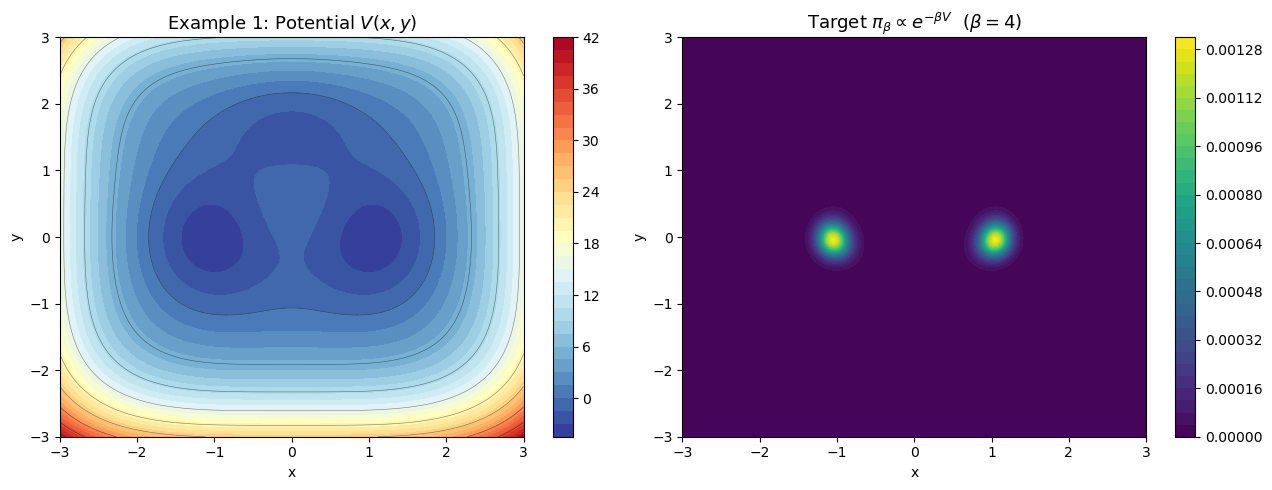

In [3]:
xg = np.linspace(ZMIN_ex1, ZMAX_ex1, 300)
yg = np.linspace(YMIN_ex1, YMAX_ex1, 300)
XX, YY = np.meshgrid(xg, yg)

VV      = V_ex1(XX, YY)
pi_beta = np.exp(-beta_ex1 * VV)
pi_beta /= pi_beta.sum()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

c0 = axes[0].contourf(XX, YY, VV, levels=40, cmap='RdYlBu_r')
axes[0].contour(XX, YY, VV, levels=10, colors='k', linewidths=0.4, alpha=0.5)
plt.colorbar(c0, ax=axes[0])
axes[0].set_title(r"Example 1: Potential $V(x,y)$", fontsize=13)
axes[0].set_xlabel("x"); axes[0].set_ylabel("y")

c1 = axes[1].contourf(XX, YY, pi_beta, levels=40, cmap='viridis')
plt.colorbar(c1, ax=axes[1])
axes[1].set_title(r"Target $\pi_\beta \propto e^{-\beta V}$  ($\beta=%g$)" % beta_ex1,
                  fontsize=13)
axes[1].set_xlabel("x"); axes[1].set_ylabel("y")

plt.tight_layout()
plt.show()


## Helper functions

### Gaussian kernels

$$
K_h(x) = \frac{1}{h \sqrt{2\pi}} \exp\!\left(-\tfrac12 (x/h)^2\right), \qquad
K_\eta(x) = \frac{1}{\eta \sqrt{2\pi}} \exp\!\left(-\tfrac12 (x/\eta)^2\right).
$$

### Marginal density via KDE

`compute_p_hat(x_eval, X, zmin, zmax, eta)` returns a Gaussian KDE estimate of
$\hat p(x)$ at the points `x_eval`, with reflections about `zmin` and `zmax`
so that mass does not leak out of the simulation domain.

### Running ABF estimator

`init_abf_accumulators` / `update_abf_accumulators` maintain the
Nadaraya--Watson sums
$$
\text{num}_n(z) = \sum_{k \le n} \sum_i K_h(z - X_k^i)\,\partial_x V(X_k^i, Y_k^i),
\qquad
\text{den}_n(z) = \sum_{k \le n} \sum_i K_h(z - X_k^i),
$$
and $\hat A_n'(z) = \text{num}_n(z) / \text{den}_n(z)$.


In [4]:
def gaussian_kernel(u, bw):
    return np.exp(-0.5 * (u / bw)**2) / (bw * np.sqrt(2.0 * np.pi))


def compute_p_hat(x_eval, X_tilde, zmin, zmax, eta):
    """KDE of the x-marginal on a grid or particle set, with boundary reflections."""
    x_eval  = np.atleast_1d(np.asarray(x_eval, dtype=float))
    N_part  = len(X_tilde)
    X_left  = 2.0 * zmin - X_tilde
    X_right = 2.0 * zmax - X_tilde
    X_all   = np.concatenate([X_left, X_tilde, X_right])
    diff    = x_eval[:, None] - X_all[None, :]
    p       = np.sum(gaussian_kernel(diff, eta), axis=1) / N_part
    return np.maximum(p, EPS)


def init_abf_accumulators(n_grid):
    return np.zeros(n_grid), np.zeros(n_grid)


def update_abf_accumulators(num_acc, den_acc, X, Y, z_grid, dVdx_func, h):
    """In-place running-average ABF update from the current particle batch."""
    diff     = z_grid[:, None] - X[None, :]
    weights  = gaussian_kernel(diff, h)
    num_acc += np.sum(weights * dVdx_func(X, Y)[None, :], axis=1)
    den_acc += np.sum(weights, axis=1)


def compute_abf_prime_from_acc(num_acc, den_acc):
    return num_acc / np.maximum(den_acc, EPS)


def integrate_abf_prime(Ahat_prime, z_grid):
    """Trapezoidal antiderivative of Ahat_prime, pinned to 0 at z nearest 0."""
    Ahat  = integrate.cumulative_trapezoid(Ahat_prime, z_grid, initial=0.0)
    idx0  = np.argmin(np.abs(z_grid))
    Ahat -= Ahat[idx0]
    return Ahat


def make_abf_interpolant(Ahat_prime, z_grid):
    return interp1d(z_grid, Ahat_prime, kind='linear',
                    bounds_error=False,
                    fill_value=(Ahat_prime[0], Ahat_prime[-1]))


## Reference free energy and mean force

`compute_reference` is generic: it takes the potential `V_func` and its
gradient `dVdx_func` and computes
$$
Z(z) = \int e^{-\beta V(z, y)} \, dy, \qquad
F(z) = -\frac{1}{\beta} \ln \frac{Z(z)}{Z}, \qquad
F'(z) = \frac{\int \partial_x V(z, y) e^{-\beta V(z, y)} \, dy}{Z(z)}.
$$

We call it once now for Example 1.


In [5]:
def compute_reference(z_grid, y_quad, beta, V_func, dVdx_func, eps=EPS):
    """Reference free energy and mean force by y-quadrature.

    Parameters
    ----------
    z_grid, y_quad : 1-D arrays.
    beta           : inverse temperature.
    V_func         : callable (x, y) -> V.
    dVdx_func      : callable (x, y) -> dV/dx.

    Returns
    -------
    log_Z, F_ref, Fprime_ref : 1-D arrays on ``z_grid``.
    """
    n_z = len(z_grid)
    n_y = len(y_quad)

    zz = z_grid[:, None] * np.ones((1, n_y))
    yy = np.ones((n_z, 1)) * y_quad[None, :]

    phi      = beta * V_func(zz, yy)
    dvdx_mat = dVdx_func(zz, yy)

    m      = phi.min(axis=1, keepdims=True)
    w      = np.exp(-(phi - m))

    Z_stab = np.trapezoid(w, y_quad, axis=1)
    log_Z  = -m[:, 0] + np.log(np.maximum(Z_stab, eps))

    Fprime_ref = (
        np.trapezoid(dvdx_mat * w, y_quad, axis=1)
        / np.maximum(Z_stab, eps)
    )

    idx0  = np.argmin(np.abs(z_grid))
    F_ref = -(1.0 / beta) * (log_Z - log_Z[idx0])

    return log_Z, F_ref, Fprime_ref


# -- Example 1 references ---------------------------------------------------
log_Z_ex1, F_ref_ex1, Fprime_ref_ex1 = compute_reference(
    z_grid_ex1, y_quad_ex1, beta_ex1, V_ex1, dVdx_ex1
)

_lz_ex1      = log_Z_ex1 - log_Z_ex1.max()
_p_unnorm    = np.exp(_lz_ex1)
p_ref_unbiased_ex1 = _p_unnorm / np.trapezoid(_p_unnorm, z_grid_ex1)


### Reference visualization (Example 1)

The reference free energy and mean force along the reaction coordinate, and
the unbiased $x$-marginal $p_\text{ref}(x) \propto Z(x)$.


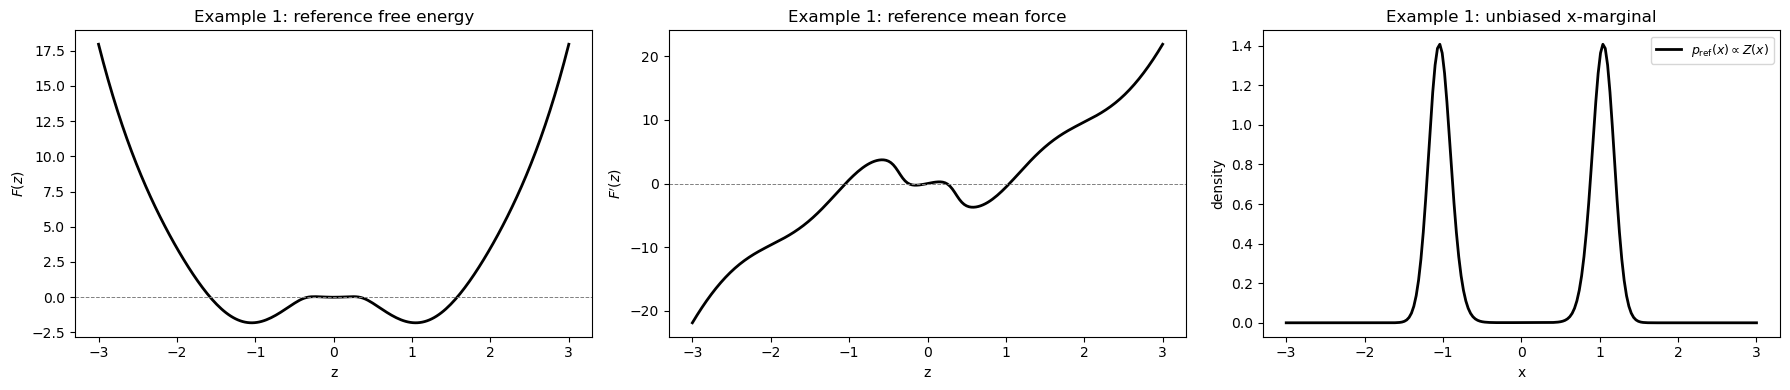

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(z_grid_ex1, F_ref_ex1, 'k-', lw=2)
axes[0].axhline(0, color='gray', lw=0.7, ls='--')
axes[0].set_xlabel("z"); axes[0].set_ylabel(r"$F(z)$")
axes[0].set_title(r"Example 1: reference free energy")

axes[1].plot(z_grid_ex1, Fprime_ref_ex1, 'k-', lw=2)
axes[1].axhline(0, color='gray', lw=0.7, ls='--')
axes[1].set_xlabel("z"); axes[1].set_ylabel(r"$F'(z)$")
axes[1].set_title(r"Example 1: reference mean force")

axes[2].plot(z_grid_ex1, p_ref_unbiased_ex1, 'k-', lw=2,
             label=r"$p_\mathrm{ref}(x) \propto Z(x)$")
axes[2].set_xlabel("x"); axes[2].set_ylabel("density")
axes[2].set_title("Example 1: unbiased x-marginal")
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()


## Birth-death dynamics

### Estimated Fisher-Rao target

`compute_estimated_fr_target` evaluates
$$
q_n(x) \;\propto\; \exp\!\left[-\beta (\widehat F_n^{\text{target}}(x) - \hat A_n(x))\right]
$$
on the grid, normalising so $\int q_n(z)\, dz = 1$.

### Fisher-Rao score

$$
S_i = \log \frac{\hat p(\tilde X_i)}{\hat q(\tilde X_i)}
- \int \hat p(z) \log \frac{\hat p(z)}{\hat q(z)} \, dz.
$$
Both $\hat p$ and $\hat q$ are renormalised on `z_grid` before the score is
formed, so the integral is a proper $\mathrm{KL}(\hat p \,\Vert\, \hat q)$.

### Rate schedule

`gamma_schedule(step, gamma_max, fr_burnin, gamma_ramp_steps)` returns the
**effective** Fisher--Rao rate at step $n$: $0$ during burn-in, then a soft
$(1 - e^{-(n - n_\text{burnin}) / n_\text{ramp}})$ ramp to $\gamma_\text{max}$.

### Birth-death resampling

`resample_fixed_N` performs the fixed-$N$ birth--death step. **It clones and
kills the whole particle $(X^i, Y^i)$** -- the FR score depends only on $X^i$
but the particle state is the full $(X^i, Y^i)$, and the $y$-component must
travel with the $x$-component. The function returns an event dictionary
`{"n_die", "n_clone", "n_events"}`.


In [7]:
def compute_estimated_fr_target(z_grid, Fhat_target_grid, B_bias_grid,
                                beta, eps=1e-12):
    """Estimated biased x-marginal target

        q(x) propto exp(-beta * (Fhat_target(x) - B(x))),

    normalised so that int q(z) dz = 1 on ``z_grid``.
    """
    exponent = -beta * (Fhat_target_grid - B_bias_grid)
    exponent = exponent - np.max(exponent)
    q = np.exp(exponent)
    q = q / np.maximum(np.trapezoid(q, z_grid), eps)
    q = np.maximum(q, eps)
    q = q / np.maximum(np.trapezoid(q, z_grid), eps)
    return q


def score_estimated_target(X_tilde, p_hat_at_particles, p_hat_on_grid,
                           q_target_on_grid, z_grid):
    """Fisher--Rao score against an estimated biased target q.

    Renormalises ``p_hat_on_grid`` and ``q_target_on_grid`` on ``z_grid``
    so the baseline is a proper KL divergence, interpolates q to particle
    locations, then returns

        S_i = log(p_hat(X_i)/q(X_i)) - int p_hat(z) log(p_hat(z)/q(z)) dz.
    """
    Zp = np.maximum(np.trapezoid(p_hat_on_grid,   z_grid), EPS)
    Zq = np.maximum(np.trapezoid(q_target_on_grid, z_grid), EPS)
    p_grid      = p_hat_on_grid    / Zp
    q_grid      = q_target_on_grid / Zq
    p_particles = p_hat_at_particles / Zp

    q_particles = np.interp(X_tilde, z_grid, q_grid)
    q_particles = np.maximum(q_particles, EPS)

    log_ratio_grid = (
        np.log(np.maximum(p_grid, EPS))
        - np.log(np.maximum(q_grid, EPS))
    )
    baseline = np.trapezoid(p_grid * log_ratio_grid, z_grid)

    log_ratio_particles = (
        np.log(np.maximum(p_particles, EPS))
        - np.log(q_particles)
    )
    return log_ratio_particles - baseline


def gamma_schedule(step, gamma_max, fr_burnin, gamma_ramp_steps):
    """Soft-ramp effective Fisher--Rao rate at integration step ``step``."""
    if step < fr_burnin:
        return 0.0
    if gamma_ramp_steps <= 0:
        return gamma_max
    s = (step - fr_burnin) / gamma_ramp_steps
    return gamma_max * (1.0 - np.exp(-max(s, 0.0)))


def resample_fixed_N(X_tilde, Y_tilde, S, gamma, dt, rng):
    """Fixed-N birth--death resampling.

    S_i > 0  -> die   with prob 1 - exp(-gamma * S_i * dt)
    S_i < 0  -> clone with prob 1 - exp( gamma * S_i * dt)

    Clones / kills the **whole** particle (X_i, Y_i). Returns
    ``(X_new, Y_new, info)`` where ``info`` is a dict
    ``{"n_die", "n_clone", "n_events"}``.
    """
    N = len(X_tilde)
    u = rng.uniform(size=N)

    pos_mask = S > 0
    neg_mask = S < 0

    p_death = np.where(pos_mask, np.clip(1.0 - np.exp(-gamma * S * dt), 0.0, 1.0), 0.0)
    p_birth = np.where(neg_mask, np.clip(1.0 - np.exp( gamma * S * dt), 0.0, 1.0), 0.0)

    die   = pos_mask & (u < p_death)
    clone = neg_mask & (u < p_birth)
    n_die   = int(die.sum())
    n_clone = int(clone.sum())

    survivors  = np.where(~die)[0]
    clone_srcs = np.where(clone)[0]

    new_idx = list(survivors) + list(clone_srcs)

    if len(new_idx) < N:
        extra   = rng.choice(survivors, size=N - len(new_idx), replace=True)
        new_idx = new_idx + list(extra)
    elif len(new_idx) > N:
        keep    = rng.choice(len(new_idx), size=N, replace=False)
        new_idx = [new_idx[k] for k in keep]

    idx  = np.array(new_idx)
    info = {"n_die": n_die, "n_clone": n_clone, "n_events": n_die + n_clone}
    return X_tilde[idx], Y_tilde[idx], info


## Methods

Both simulation functions are generic across examples: they take the gradient
functions, the domain bounds, the bandwidths and the reference quantities as
explicit arguments, and reuse the helpers above.

### ABF only

Langevin dynamics with the adaptive biasing force, no birth--death.


In [8]:
def simulate_abf_only(
    N, dt, n_steps, save_every, beta,
    dVdx_func, dVdy_func,
    zmin, zmax, ymin, ymax,
    h, eta,
    z_grid, F_ref, Fprime_ref,
    rng=None,
    V_func=None,
):
    """ABF-only Langevin dynamics (no Fisher--Rao)."""
    if rng is None:
        rng = np.random.default_rng()

    X = rng.uniform(zmin, zmax, size=N)
    Y = rng.uniform(ymin, ymax, size=N)
    noise_scale = np.sqrt(2.0 * dt / beta)

    num_acc, den_acc = init_abf_accumulators(len(z_grid))

    diag = dict(steps=[], Ahat_prime=[], Ahat=[], p_hat_grid=[],
                l2_fprime=[], l2_f=[], X_snap=[], Y_snap=[])

    for step in range(n_steps):
        update_abf_accumulators(num_acc, den_acc, X, Y, z_grid, dVdx_func, h)
        Ahat_prime = compute_abf_prime_from_acc(num_acc, den_acc)
        Ahat       = integrate_abf_prime(Ahat_prime, z_grid)
        abf_at_X   = make_abf_interpolant(Ahat_prime, z_grid)(X)

        X_tilde = X + (-dVdx_func(X, Y) + abf_at_X) * dt + noise_scale * rng.standard_normal(N)
        Y_tilde = Y + (-dVdy_func(X, Y))            * dt + noise_scale * rng.standard_normal(N)

        X_tilde = _reflect_1d(X_tilde, zmin, zmax)
        Y_tilde = _reflect_1d(Y_tilde, ymin, ymax)

        X, Y = X_tilde, Y_tilde

        if step % save_every == 0 or step == n_steps - 1:
            p_hat_g = compute_p_hat(z_grid, X, zmin, zmax, eta)
            idx0    = np.argmin(np.abs(z_grid))
            Ahat_sh = Ahat - Ahat[idx0]
            diag['steps'].append(step)
            diag['Ahat_prime'].append(Ahat_prime.copy())
            diag['Ahat'].append(Ahat_sh.copy())
            diag['p_hat_grid'].append(p_hat_g.copy())
            diag['l2_fprime'].append(np.sqrt(np.mean((Ahat_prime - Fprime_ref)**2)))
            diag['l2_f'].append(np.sqrt(np.mean((Ahat_sh - F_ref)**2)))
            diag['X_snap'].append(X.copy())
            diag['Y_snap'].append(Y.copy())

    return diag


### ABF + Fisher-Rao with estimated target

Same dynamics as **ABF only**, plus a Fisher-Rao birth-death step against the estimated target

$$
q_n(x) \;\propto\; \exp\!\left[ -\beta \big( \widehat F_n^{\text{target}}(x) - \hat A_n (x) \big) \right].
$$

In [9]:
def simulate_abf_fr_estimated_target(
    N, dt, n_steps, save_every, beta,
    dVdx_func, dVdy_func,
    zmin, zmax, ymin, ymax,
    h, eta,
    z_grid, F_ref, Fprime_ref,
    gamma_max,
    fr_burnin=0,
    fr_every=5,
    gamma_ramp_steps=0,
    target_mode="ema",
    target_ema_rate=0.05,
    score_clip=None,
    freeze_abf_after_burnin=False,
    rng=None,
    V_func=None,
):
    """ABF + Fisher--Rao birth--death against an estimated biased target."""
    if rng is None:
        rng = np.random.default_rng()
    if target_mode not in ("ema", "current"):
        raise ValueError(f"Unknown target_mode: {target_mode!r}")
    if fr_every <= 0:
        raise ValueError("fr_every must be positive")

    X = rng.uniform(zmin, zmax, size=N)
    Y = rng.uniform(ymin, ymax, size=N)
    noise_scale = np.sqrt(2.0 * dt / beta)

    num_acc, den_acc = init_abf_accumulators(len(z_grid))
    Fhat_target_grid = np.zeros(len(z_grid))
    Ahat_prime_frozen = None
    Ahat_frozen = None

    diag = dict(
        steps=[], Ahat_prime=[], Ahat=[], p_hat_grid=[],
        q_target_grid=[], l2_fprime=[], l2_f=[],
        X_snap=[], Y_snap=[],
        fr_applied=[], fr_event_count=[], gamma_eff=[],
        fr_burnin=int(fr_burnin), fr_every=int(fr_every),
        target_mode=target_mode,
        score_clip=score_clip,
        freeze_abf_after_burnin=bool(freeze_abf_after_burnin),
    )

    fr_events_window = 0
    fr_steps_window  = 0

    for step in range(n_steps):
        # 1. ABF update from current particles. In frozen mode, stop changing
        # the estimator once the burn-in estimate has been saved.
        update_online_abf = (
            (not freeze_abf_after_burnin)
            or (Ahat_prime_frozen is None)
            or (step <= fr_burnin)
        )
        if update_online_abf:
            update_abf_accumulators(num_acc, den_acc, X, Y, z_grid, dVdx_func, h)
            Ahat_prime_online = compute_abf_prime_from_acc(num_acc, den_acc)
            Ahat_online       = integrate_abf_prime(Ahat_prime_online, z_grid)
            if freeze_abf_after_burnin and step >= fr_burnin and Ahat_prime_frozen is None:
                Ahat_prime_frozen = Ahat_prime_online.copy()
                Ahat_frozen       = Ahat_online.copy()
        else:
            Ahat_prime_online = Ahat_prime_frozen
            Ahat_online       = Ahat_frozen

        if freeze_abf_after_burnin and Ahat_prime_frozen is not None and step >= fr_burnin:
            Ahat_prime = Ahat_prime_frozen
            Ahat       = Ahat_frozen
        else:
            Ahat_prime = Ahat_prime_online
            Ahat       = Ahat_online

        abf_at_X = make_abf_interpolant(Ahat_prime, z_grid)(X)

        # 2. Update target free-energy estimate from the force estimate that is
        # actually allowed to drive the post-burn-in dynamics.
        if target_mode == "current":
            Fhat_target_grid = Ahat.copy()
        else:  # "ema"
            Fhat_target_grid = (
                (1.0 - target_ema_rate) * Fhat_target_grid
                + target_ema_rate * Ahat
            )

        # 3. Langevin + ABF proposal
        X_tilde = X + (-dVdx_func(X, Y) + abf_at_X) * dt + noise_scale * rng.standard_normal(N)
        Y_tilde = Y + (-dVdy_func(X, Y))            * dt + noise_scale * rng.standard_normal(N)
        X_tilde = _reflect_1d(X_tilde, zmin, zmax)
        Y_tilde = _reflect_1d(Y_tilde, ymin, ymax)

        # 4. Decide if FR is applied at this step
        gamma_eff = gamma_schedule(step, gamma_max, fr_burnin, gamma_ramp_steps)
        do_fr = (step >= fr_burnin) and ((step - fr_burnin) % fr_every == 0) and (gamma_eff > 0.0)

        if do_fr:
            B_bias_grid = Ahat
            q_target_grid = compute_estimated_fr_target(
                z_grid, Fhat_target_grid, B_bias_grid, beta
            )
            p_hat_on_grid      = compute_p_hat(z_grid,  X_tilde, zmin, zmax, eta)
            p_hat_at_particles = compute_p_hat(X_tilde, X_tilde, zmin, zmax, eta)
            S = score_estimated_target(
                X_tilde, p_hat_at_particles, p_hat_on_grid,
                q_target_grid, z_grid
            )
            if score_clip is not None:
                S = np.clip(S, -score_clip, score_clip)
            X_new, Y_new, info = resample_fixed_N(
                X_tilde, Y_tilde, S, gamma_eff, dt, rng
            )
            X, Y = X_new, Y_new
            fr_events_window += info["n_events"]
            fr_steps_window  += 1
        else:
            X, Y = X_tilde, Y_tilde

        # 5. Snapshot
        if step % save_every == 0 or step == n_steps - 1:
            p_hat_g = compute_p_hat(z_grid, X, zmin, zmax, eta)
            idx0    = np.argmin(np.abs(z_grid))
            Ahat_sh = Ahat - Ahat[idx0]
            q_target_save = compute_estimated_fr_target(
                z_grid, Fhat_target_grid, Ahat, beta
            )
            diag['steps'].append(step)
            diag['Ahat_prime'].append(Ahat_prime.copy())
            diag['Ahat'].append(Ahat_sh.copy())
            diag['p_hat_grid'].append(p_hat_g.copy())
            diag['q_target_grid'].append(q_target_save.copy())
            diag['l2_fprime'].append(np.sqrt(np.mean((Ahat_prime - Fprime_ref)**2)))
            diag['l2_f'].append(np.sqrt(np.mean((Ahat_sh - F_ref)**2)))
            diag['X_snap'].append(X.copy())
            diag['Y_snap'].append(Y.copy())
            diag['fr_applied'].append(bool(fr_steps_window > 0))
            diag['fr_event_count'].append(int(fr_events_window))
            diag['gamma_eff'].append(float(gamma_eff))
            fr_events_window = 0
            fr_steps_window  = 0

    return diag


## Simulation (Example 1)

In [10]:
import time

common_kw_ex1 = dict(
    N=N_ex1, dt=dt_ex1, n_steps=n_steps_ex1, save_every=save_every_ex1,
    beta=beta_ex1,
    dVdx_func=dVdx_ex1, dVdy_func=dVdy_ex1,
    zmin=ZMIN_ex1, zmax=ZMAX_ex1, ymin=YMIN_ex1, ymax=YMAX_ex1,
    h=h_ex1, eta=eta_ex1,
    z_grid=z_grid_ex1, F_ref=F_ref_ex1, Fprime_ref=Fprime_ref_ex1,
    V_func=V_ex1,
)

seed_ex1 = int(rng.integers(0, 2**31))

print("Example 1 -- ABF only ...", end=" ", flush=True)
t0 = time.time()
diag_abf_ex1 = simulate_abf_only(
    **common_kw_ex1, rng=np.random.default_rng(seed_ex1)
)
print(f"done in {time.time()-t0:.1f}s")

print("Example 1 -- ABF + Fisher-Rao ...", end=" ", flush=True)
t0 = time.time()
diag_fr_ex1 = simulate_abf_fr_estimated_target(
    **common_kw_ex1,
    gamma_max=gamma_ex1,
    fr_burnin=fr_burnin_ex1,
    fr_every=fr_every_ex1,
    gamma_ramp_steps=gamma_ramp_steps_ex1,
    target_mode=target_mode_ex1,
    target_ema_rate=target_ema_rate_ex1,
    rng=np.random.default_rng(seed_ex1),
)
print(f"done in {time.time()-t0:.1f}s")

print("\nFinal L2 errors (Example 1):")
for lbl, d in [("ABF only", diag_abf_ex1), ("ABF + FR", diag_fr_ex1)]:
    print(f"  {lbl:10s}: F' RMS = {d['l2_fprime'][-1]:.4f},   F RMS = {d['l2_f'][-1]:.4f}")
print(f"\nFisher--Rao birth/death events (Example 1): "
      f"{sum(diag_fr_ex1['fr_event_count'])} over {n_steps_ex1} steps "
      f"(fr_burnin={diag_fr_ex1['fr_burnin']}, fr_every={diag_fr_ex1['fr_every']}, "
      f"target_mode={diag_fr_ex1['target_mode']!r})")


Example 1 -- ABF only ... done in 17.6s
Example 1 -- ABF + Fisher-Rao ... done in 35.7s

Final L2 errors (Example 1):
  ABF only  : F' RMS = 0.4200,   F RMS = 0.4052
  ABF + FR  : F' RMS = 0.3921,   F RMS = 0.3725

Fisher--Rao birth/death events (Example 1): 9 over 6000 steps (fr_burnin=1200, fr_every=5, target_mode='ema')


### Per-method diagnostics (Example 1)

For each method we plot, side-by-side: the final mean-force estimate, the
final free-energy estimate, the final $x$-marginal $\hat p(x)$ together with
the estimated target $\hat q(x)$ (only available for ABF + FR), and the
particle scatter in $(x, y)$.


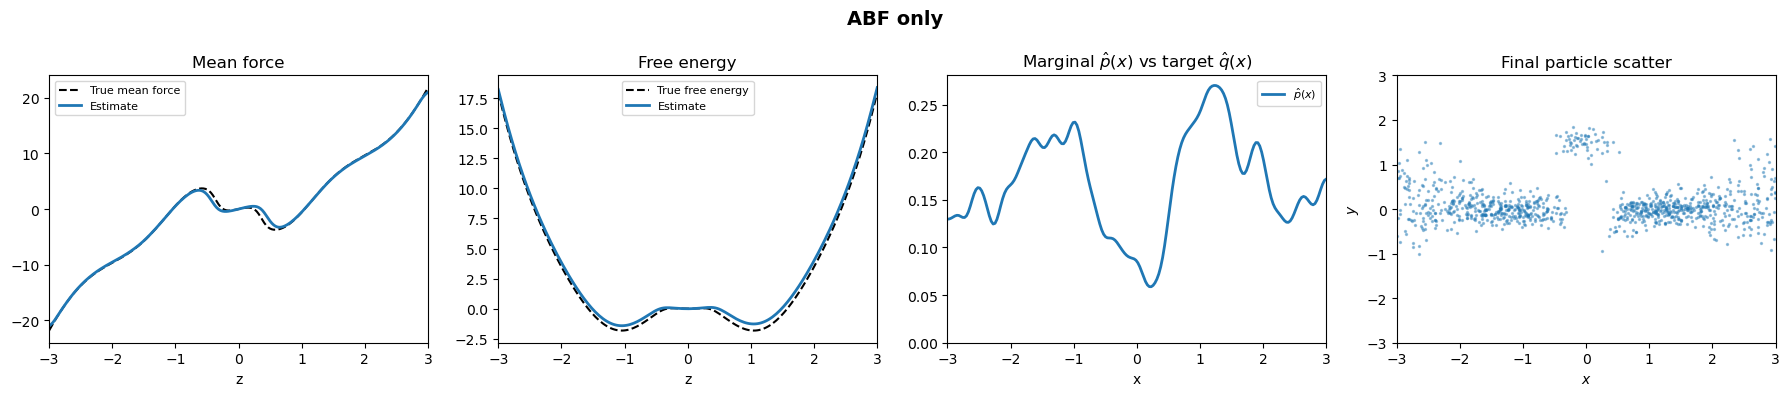

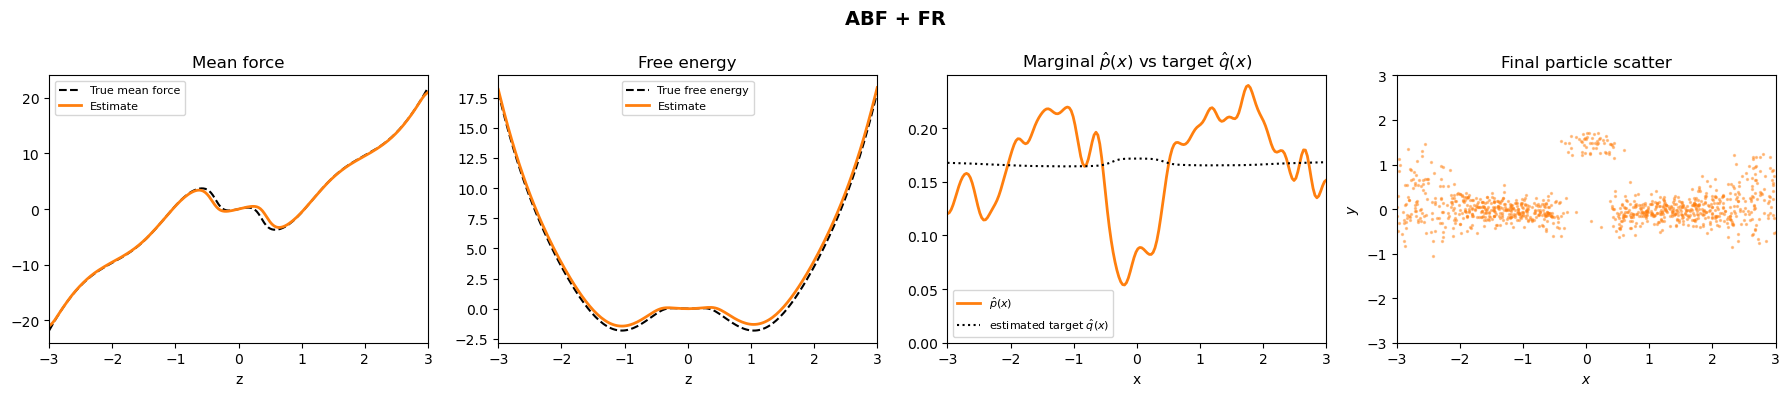

In [11]:
def plot_method_diagnostics(label, d, color, z_grid, F_ref, Fprime_ref,
                            zmin, zmax, ymin, ymax):
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    fig.suptitle(label, fontsize=14, fontweight='bold')

    ax = axes[0]
    ax.plot(z_grid, Fprime_ref, 'k--', lw=1.5, label="True mean force")
    ax.plot(z_grid, d['Ahat_prime'][-1], color=color, lw=2, label="Estimate")
    ax.set_xlabel("z"); ax.set_title("Mean force")
    ax.legend(fontsize=8); ax.set_xlim(zmin, zmax)

    ax = axes[1]
    ax.plot(z_grid, F_ref, 'k--', lw=1.5, label="True free energy")
    ax.plot(z_grid, d['Ahat'][-1], color=color, lw=2, label="Estimate")
    ax.set_xlabel("z"); ax.set_title("Free energy")
    ax.legend(fontsize=8); ax.set_xlim(zmin, zmax)

    ax = axes[2]
    ax.plot(z_grid, d['p_hat_grid'][-1], color=color, lw=2,
            label=r"$\hat p(x)$")
    if 'q_target_grid' in d and len(d['q_target_grid']) > 0:
        ax.plot(z_grid, d['q_target_grid'][-1], color='k', lw=1.5, ls=':',
                label=r"estimated target $\hat q(x)$")
    ax.set_xlabel("x")
    ax.set_title(r"Marginal $\hat p(x)$ vs target $\hat q(x)$")
    ax.legend(fontsize=8); ax.set_xlim(zmin, zmax); ax.set_ylim(bottom=0)

    ax = axes[3]
    Xs, Ys = d['X_snap'][-1], d['Y_snap'][-1]
    ax.scatter(Xs, Ys, s=2, alpha=0.4, color=color, rasterized=True)
    ax.set_xlim(zmin, zmax); ax.set_ylim(ymin, ymax)
    ax.set_xlabel(r"$x$"); ax.set_ylabel(r"$y$")
    ax.set_title("Final particle scatter")

    plt.tight_layout()
    plt.show()


methods_ex1 = [
    ("ABF only", diag_abf_ex1, "C0"),
    ("ABF + FR", diag_fr_ex1,  "C1"),
]
for label, d, col in methods_ex1:
    plot_method_diagnostics(
        label, d, col, z_grid_ex1, F_ref_ex1, Fprime_ref_ex1,
        ZMIN_ex1, ZMAX_ex1, YMIN_ex1, YMAX_ex1,
    )


### Method comparison (Example 1)

Time series of the L$_2$ errors of the mean force and the free energy, the
Fisher--Rao event count per save window, and the effective FR rate
$\gamma_n^{\text{eff}}$. The vertical dashed line marks the end of the
Fisher--Rao burn-in window.


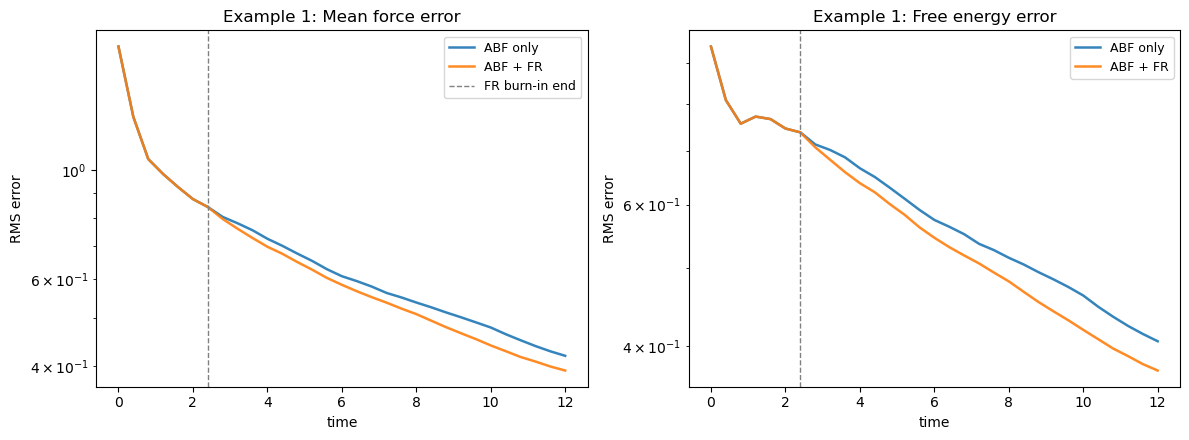

In [12]:
def plot_method_comparison(methods, dt, n_steps, fr_diag, title_prefix=""):
    """methods: list of (label, diag, color). fr_diag: the ABF+FR diag (for FR curves)."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    # 1. Mean-force L2
    ax = axes[0]
    for lbl, d, col in methods:
        t_arr = np.array(d['steps']) * dt
        ax.plot(t_arr, d['l2_fprime'], color=col, lw=1.8, label=lbl, alpha=0.9)
    ax.axvline(fr_diag['fr_burnin'] * dt, color='gray', ls='--', lw=1.0,
               label="FR burn-in end")
    ax.set_xlabel("time"); ax.set_ylabel("RMS error")
    ax.set_title(f"{title_prefix}Mean force error".strip()); ax.legend(fontsize=9)
    ax.set_yscale('log')

    # 2. Free-energy L2
    ax = axes[1]
    for lbl, d, col in methods:
        t_arr = np.array(d['steps']) * dt
        ax.plot(t_arr, d['l2_f'], color=col, lw=1.8, label=lbl, alpha=0.9)
    ax.axvline(fr_diag['fr_burnin'] * dt, color='gray', ls='--', lw=1.0)
    ax.set_xlabel("time"); ax.set_ylabel("RMS error")
    ax.set_title(f"{title_prefix}Free energy error".strip()); ax.legend(fontsize=9)
    ax.set_yscale('log')

    plt.tight_layout()
    plt.show()


plot_method_comparison(methods_ex1, dt_ex1, n_steps_ex1, diag_fr_ex1,
                       title_prefix="Example 1: ")


## Example 2 -- metastable dynamics

$$
V(x, y) = \tfrac{1}{6}\left[ 4(1 - x^2 - y^2)^2 + 2(x^2 - 2)^2
+ ((x + y)^2 - 1)^2 + ((x - y)^2 - 1)^2 \right]
$$
with the same reaction coordinate $\xi(x, y) = x$.


### Local setup (Example 2)

In [13]:
# -- Example 2 domain -------------------------------------------------------
ZMIN_ex2, ZMAX_ex2 = -1.8, 1.8
YMIN_ex2, YMAX_ex2 = -1.8, 1.8

# -- Example 2 physical parameter -------------------------------------------
beta_ex2 = 6.0

# -- Example 2 particle / time parameters -----------------------------------
N_ex2          = 1000        # was 600 -- more particles -> stabler KDE
dt_ex2         = 1e-3
n_steps_ex2    = 6000        # was 3000 -- longer for FR to act
save_every_ex2 = 200

# -- Example 2 Fisher--Rao parameters ---------------------------------------
gamma_ex2            = 5.0                          # was 1.0 -- stronger FR forcing
fr_burnin_ex2        = int(0.15 * n_steps_ex2)      # was 0.30 -- start FR earlier
fr_every_ex2         = 2                            # was 5    -- apply FR more often
gamma_ramp_steps_ex2 = int(0.10 * n_steps_ex2)      # was 0.20 -- faster ramp
target_mode_ex2      = "ema"
target_ema_rate_ex2  = 0.01                         # was 0.05 -- slower target tracking,
                                                    #            keeps q meaningfully non-uniform

# -- Example 2 bandwidths ---------------------------------------------------
h_ex2   = 0.06    # was 0.04 -- slightly wider ABF kernel
eta_ex2 = 0.06    # was 0.02 -- much wider KDE bandwidth for stable FR score

# -- Example 2 reference / diagnostic grid ----------------------------------
n_grid_ex2 = 200
z_grid_ex2 = np.linspace(ZMIN_ex2, ZMAX_ex2, n_grid_ex2)
dz_ex2     = z_grid_ex2[1] - z_grid_ex2[0]

# -- Example 2 quadrature grid for y-integrals in reference computation -----
n_quad_ex2 = 200
y_quad_ex2 = np.linspace(YMIN_ex2, YMAX_ex2, n_quad_ex2)


def V_ex2(x, y):
    a = 1.0 - x**2 - y**2
    b = x**2 - 2.0
    c = (x + y)**2 - 1.0
    d = (x - y)**2 - 1.0
    return (4.0 * a**2 + 2.0 * b**2 + c**2 + d**2) / 6.0


def dVdx_ex2(x, y):
    a = 1.0 - x**2 - y**2
    b = x**2 - 2.0
    c = (x + y)**2 - 1.0
    d = (x - y)**2 - 1.0
    return (
        -16.0 * x * a
        +  8.0 * x * b
        +  4.0 * c * (x + y)
        +  4.0 * d * (x - y)
    ) / 6.0


def dVdy_ex2(x, y):
    a = 1.0 - x**2 - y**2
    c = (x + y)**2 - 1.0
    d = (x - y)**2 - 1.0
    return (
        -16.0 * y * a
        +  4.0 * c * (x + y)
        -  4.0 * d * (x - y)
    ) / 6.0


### Visualization of potential and target distribution (Example 2)


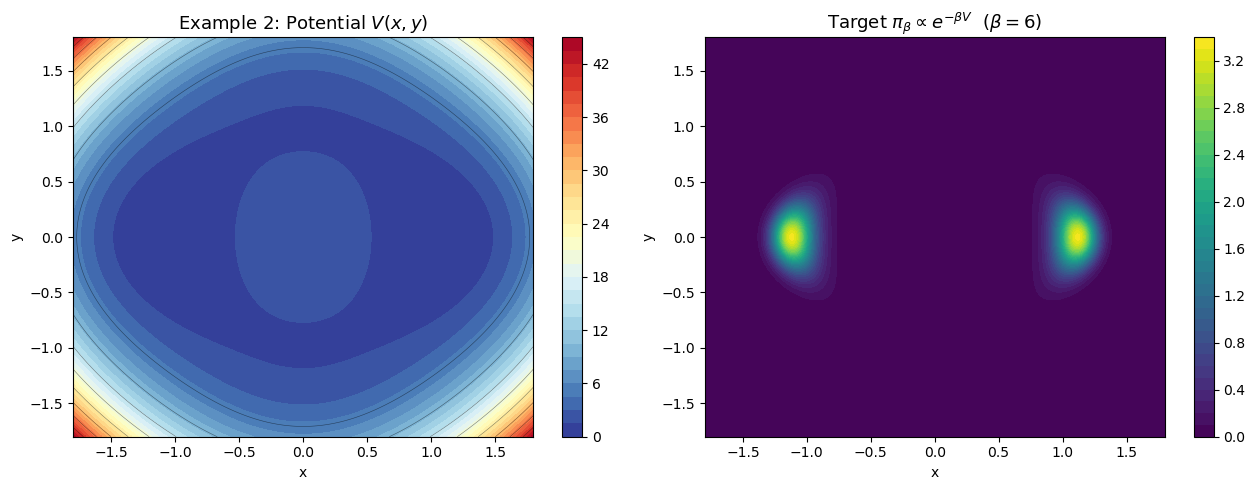

In [14]:
xg_ex2 = np.linspace(ZMIN_ex2, ZMAX_ex2, 300)
yg_ex2 = np.linspace(YMIN_ex2, YMAX_ex2, 300)
XX_ex2, YY_ex2 = np.meshgrid(xg_ex2, yg_ex2)

VV_ex2 = V_ex2(XX_ex2, YY_ex2)
pi_beta_raw_ex2 = np.exp(-beta_ex2 * (VV_ex2 - np.min(VV_ex2)))
norm_pi_ex2 = np.trapezoid(
    np.trapezoid(pi_beta_raw_ex2, xg_ex2, axis=1), yg_ex2
)
pi_beta_ex2 = pi_beta_raw_ex2 / norm_pi_ex2

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

c0 = axes[0].contourf(XX_ex2, YY_ex2, VV_ex2, levels=40, cmap='RdYlBu_r')
axes[0].contour(XX_ex2, YY_ex2, VV_ex2, levels=10, colors='k', linewidths=0.4, alpha=0.5)
plt.colorbar(c0, ax=axes[0])
axes[0].set_title(r"Example 2: Potential $V(x,y)$", fontsize=13)
axes[0].set_xlabel("x"); axes[0].set_ylabel("y")

c1 = axes[1].contourf(XX_ex2, YY_ex2, pi_beta_ex2, levels=40, cmap='viridis')
plt.colorbar(c1, ax=axes[1])
axes[1].set_title(r"Target $\pi_\beta \propto e^{-\beta V}$  ($\beta=%g$)" % beta_ex2,
                  fontsize=13)
axes[1].set_xlabel("x"); axes[1].set_ylabel("y")

plt.tight_layout()
plt.show()


### Reference free energy and mean force (Example 2)

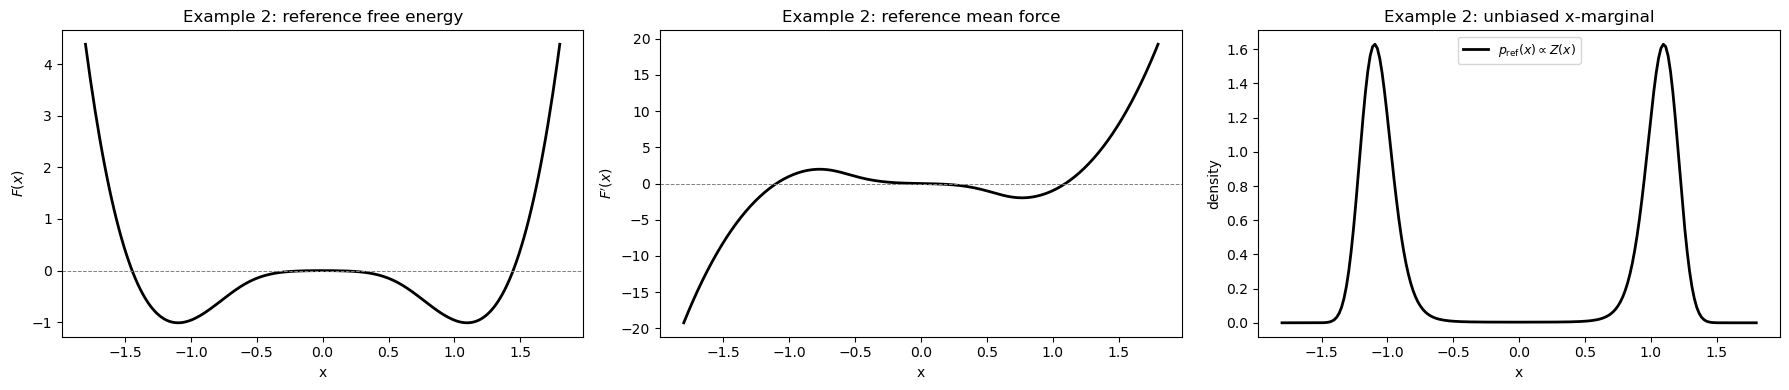

In [15]:
log_Z_ex2, F_ref_ex2, Fprime_ref_ex2 = compute_reference(
    z_grid_ex2, y_quad_ex2, beta_ex2, V_ex2, dVdx_ex2
)

_lz_ex2      = log_Z_ex2 - log_Z_ex2.max()
_p_unnorm    = np.exp(_lz_ex2)
p_ref_unbiased_ex2 = _p_unnorm / np.trapezoid(_p_unnorm, z_grid_ex2)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(z_grid_ex2, F_ref_ex2, 'k-', lw=2)
axes[0].axhline(0, color='gray', lw=0.7, ls='--')
axes[0].set_xlabel("x"); axes[0].set_ylabel(r"$F(x)$")
axes[0].set_title(r"Example 2: reference free energy")

axes[1].plot(z_grid_ex2, Fprime_ref_ex2, 'k-', lw=2)
axes[1].axhline(0, color='gray', lw=0.7, ls='--')
axes[1].set_xlabel("x"); axes[1].set_ylabel(r"$F'(x)$")
axes[1].set_title(r"Example 2: reference mean force")

axes[2].plot(z_grid_ex2, p_ref_unbiased_ex2, 'k-', lw=2,
             label=r"$p_\mathrm{ref}(x) \propto Z(x)$")
axes[2].set_xlabel("x"); axes[2].set_ylabel("density")
axes[2].set_title("Example 2: unbiased x-marginal")
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()


### Simulation (Example 2)

In [16]:
common_kw_ex2 = dict(
    N=N_ex2, dt=dt_ex2, n_steps=n_steps_ex2, save_every=save_every_ex2,
    beta=beta_ex2,
    dVdx_func=dVdx_ex2, dVdy_func=dVdy_ex2,
    zmin=ZMIN_ex2, zmax=ZMAX_ex2, ymin=YMIN_ex2, ymax=YMAX_ex2,
    h=h_ex2, eta=eta_ex2,
    z_grid=z_grid_ex2, F_ref=F_ref_ex2, Fprime_ref=Fprime_ref_ex2,
    V_func=V_ex2,
)

rng_ex2   = np.random.default_rng(31415)
seed_ex2 = int(rng_ex2.integers(0, 2**31))

print("Example 2 -- ABF only ...", end=" ", flush=True)
t0 = time.time()
diag_abf_ex2 = simulate_abf_only(
    **common_kw_ex2, rng=np.random.default_rng(seed_ex2)
)
print(f"done in {time.time()-t0:.1f}s")

print("Example 2 -- ABF + Fisher-Rao ...", end=" ", flush=True)
t0 = time.time()
diag_fr_ex2 = simulate_abf_fr_estimated_target(
    **common_kw_ex2,
    gamma_max=gamma_ex2,
    fr_burnin=fr_burnin_ex2,
    fr_every=fr_every_ex2,
    gamma_ramp_steps=gamma_ramp_steps_ex2,
    target_mode=target_mode_ex2,
    target_ema_rate=target_ema_rate_ex2,
    rng=np.random.default_rng(seed_ex2),
)
print(f"done in {time.time()-t0:.1f}s")

print("\nFinal L2 errors (Example 2):")
for lbl, d in [("ABF only", diag_abf_ex2), ("ABF + FR", diag_fr_ex2)]:
    print(f"  {lbl:10s}: F' RMS = {d['l2_fprime'][-1]:.4f},   F RMS = {d['l2_f'][-1]:.4f}")
print(f"\nFisher--Rao birth/death events (Example 2): "
      f"{sum(diag_fr_ex2['fr_event_count'])} over {n_steps_ex2} steps "
      f"(fr_burnin={diag_fr_ex2['fr_burnin']}, fr_every={diag_fr_ex2['fr_every']}, "
      f"target_mode={diag_fr_ex2['target_mode']!r})")


Example 2 -- ABF only ... done in 8.6s
Example 2 -- ABF + Fisher-Rao ... done in 66.1s

Final L2 errors (Example 2):
  ABF only  : F' RMS = 0.5413,   F RMS = 0.3836
  ABF + FR  : F' RMS = 0.4720,   F RMS = 0.3027

Fisher--Rao birth/death events (Example 2): 2806 over 6000 steps (fr_burnin=900, fr_every=2, target_mode='ema')


### Per-method diagnostics (Example 2)


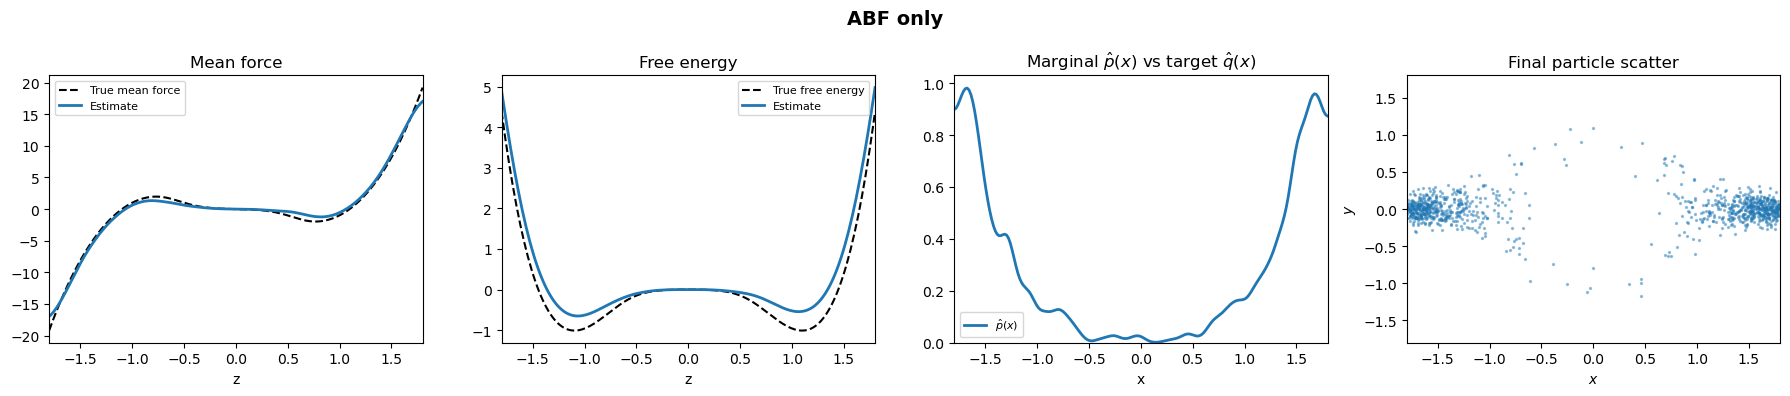

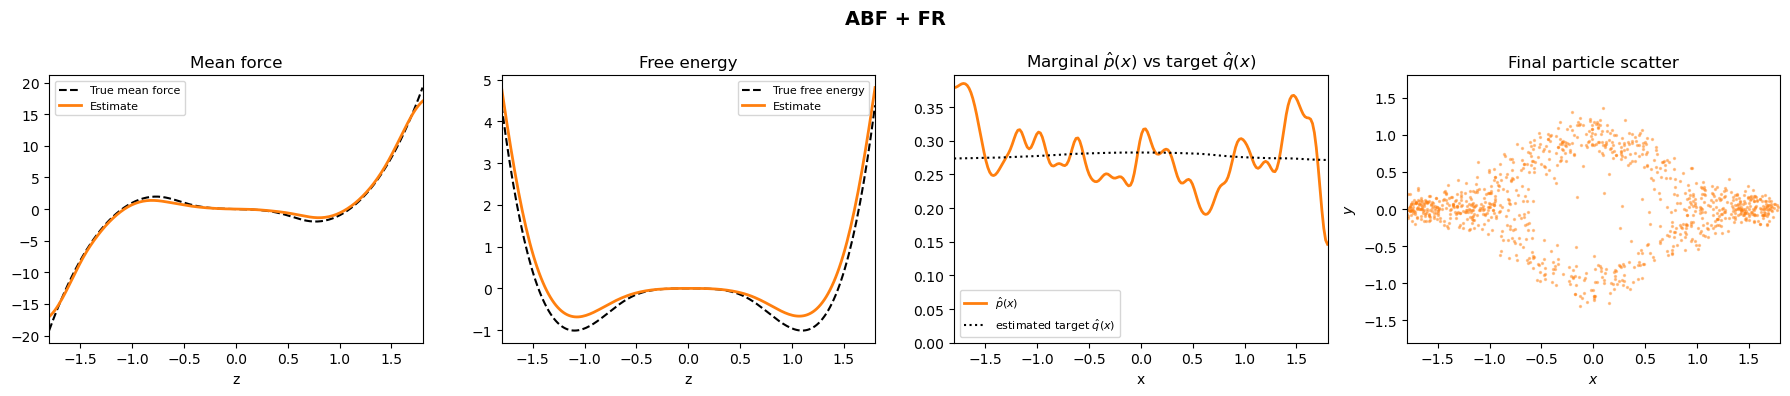

In [17]:
methods_ex2 = [
    ("ABF only", diag_abf_ex2, "C0"),
    ("ABF + FR", diag_fr_ex2,  "C1"),
]
for label, d, col in methods_ex2:
    plot_method_diagnostics(
        label, d, col, z_grid_ex2, F_ref_ex2, Fprime_ref_ex2,
        ZMIN_ex2, ZMAX_ex2, YMIN_ex2, YMAX_ex2,
    )


### Method comparison (Example 2)


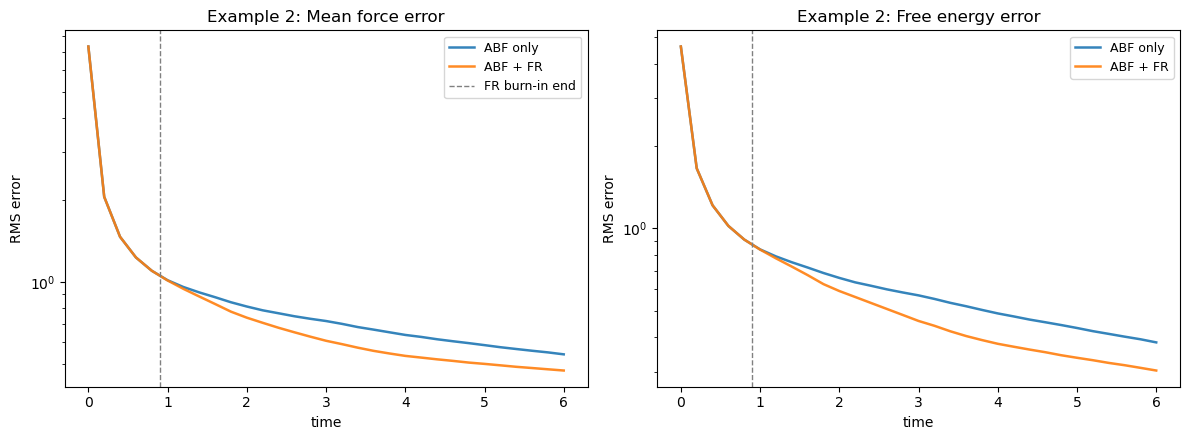

In [18]:
plot_method_comparison(methods_ex2, dt_ex2, n_steps_ex2, diag_fr_ex2,
                       title_prefix="Example 2: ")
